## Phase 1 — Collecting Data

This phase focus on fetching the data from yfinance and plotting price in case of Gold and returns for other v/s the timeline.

The order of charts are (though they are named):
- **Gold**
- **Apple**
- **HDFC**
- **Reliance**


In [1]:
import pandas as pd 
import matplotlib.pyplot as plt

In [2]:
import yfinance as yf

gold_raw = yf.download('GOLDBEES.NS', start='2010-01-01', interval='1d', progress=False, auto_adjust=True)

if isinstance(gold_raw.columns, pd.MultiIndex):
    gold_raw.columns = gold_raw.columns.get_level_values(0)

df_gold = gold_raw.reset_index()[['Date', 'Close']].rename(columns={'Close': 'Price'})
df_gold['Date'] = pd.to_datetime(df_gold['Date']).dt.tz_localize(None)
df_gold = df_gold.dropna().sort_values('Date').reset_index(drop=True)

df_gold['Returns'] = df_gold['Price'].pct_change() * 100
df_gold = df_gold.dropna().reset_index(drop=True)

print(f"Gold (GOLDBEES.NS) raw data: {df_gold['Date'].min().date()} to {df_gold['Date'].max().date()} ({len(df_gold)} rows)")

suspects = df_gold[df_gold['Returns'].abs() > 15].copy()

if len(suspects) > 0:
    print(f"\nFound {len(suspects)} suspicious single-day move(s) > 15%:")
    print(suspects[['Date', 'Price', 'Returns']])

    for idx in suspects.index:
        if idx == 0 or idx >= len(df_gold) - 1:
            continue
        price_before = df_gold.loc[idx - 1, 'Price']
        price_spike = df_gold.loc[idx, 'Price']
        price_after = df_gold.loc[idx + 1, 'Price']

        if abs(price_after / price_before - 1) < 0.15:
            df_gold.loc[idx, 'Price'] = (price_before + price_after) / 2
            print(f"  {df_gold.loc[idx, 'Date'].date()}: single bad print (reverted next day) - interpolated.")
        else:
            ratio = price_spike / price_before
            df_gold.loc[:idx - 1, 'Price'] = df_gold.loc[:idx - 1, 'Price'] * ratio
            print(f"  {df_gold.loc[idx, 'Date'].date()}: persistent level shift (ratio={ratio:.2f}) "
                  f"- treated as an un-adjusted split, rescaled prices before this date.")

    # Recompute returns from the cleaned price series
    df_gold['Returns'] = df_gold['Price'].pct_change() * 100
    df_gold = df_gold.dropna().reset_index(drop=True)

    remaining = df_gold.reindex(df_gold['Returns'].abs().sort_values(ascending=False).index).head(5)
    print("\nLargest remaining single-day moves after cleaning (should all look plausible now):")
    print(remaining[['Date', 'Price', 'Returns']])
else:
    print("No suspicious single-day price moves found.")

print(f"\nFinal Gold (GOLDBEES.NS) data: {df_gold['Date'].min().date()} to {df_gold['Date'].max().date()} ({len(df_gold)} rows)")
print(df_gold.head())


Gold (GOLDBEES.NS) raw data: 2010-01-05 to 2026-07-10 (4076 rows)

Found 2 suspicious single-day move(s) > 15%:
Price       Date      Price      Returns
2451  2019-12-19   0.335500   -99.001369
2453  2019-12-23  33.650002  9900.000779
  2019-12-19: persistent level shift (ratio=0.01) - treated as an un-adjusted split, rescaled prices before this date.
  2019-12-23: persistent level shift (ratio=100.00) - treated as an un-adjusted split, rescaled prices before this date.

Largest remaining single-day moves after cleaning (should all look plausible now):
Price       Date       Price    Returns
3964  2026-01-30  131.119995 -10.516620
3965  2026-02-02  118.669998  -9.495117
3999  2026-03-23  110.720001  -8.541216
3963  2026-01-29  146.529999   7.885430
3959  2026-01-22  124.339996  -7.875828

Final Gold (GOLDBEES.NS) data: 2010-01-06 to 2026-07-10 (4075 rows)
Price       Date      Price   Returns
0     2010-01-06  16.577273 -0.479616
1     2010-01-07  16.549311 -0.168674
2     2010-01-08  

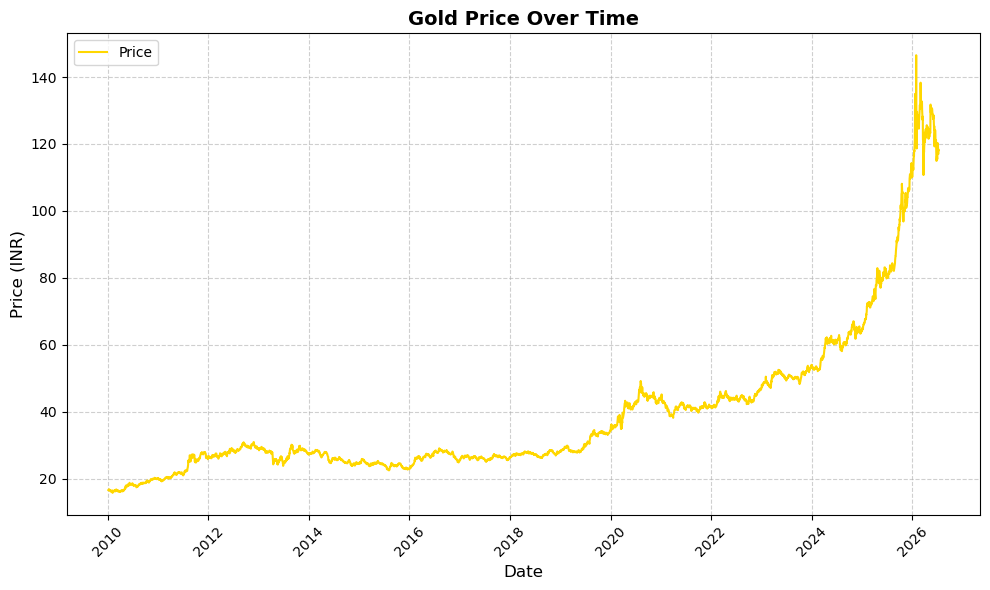

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df_gold['Date'], df_gold['Price'], label='Price', color='gold', linewidth=1.5)
ax.set_title('Gold Price Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price (INR)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [4]:
import yfinance as yf

# Pull Apple prices directly from Yahoo Finance.
apple_raw = yf.download('AAPL', start='2010-01-01', interval='1d', progress=False, auto_adjust=True)

if isinstance(apple_raw.columns, pd.MultiIndex):
    apple_raw.columns = apple_raw.columns.get_level_values(0)

df_apple = apple_raw.reset_index()[['Date', 'Close']].rename(columns={'Close': 'Price'})
df_apple['Date'] = pd.to_datetime(df_apple['Date']).dt.tz_localize(None)
df_apple = df_apple.dropna().sort_values('Date').reset_index(drop=True)

df_apple['Returns'] = df_apple['Price'].pct_change() * 100
df_apple = df_apple.dropna().reset_index(drop=True)

print(f"Apple (AAPL) data: {df_apple['Date'].min().date()} to {df_apple['Date'].max().date()} ({len(df_apple)} rows)")
print("Missing values check:", df_apple[['Price', 'Returns']].isna().sum().to_dict())

# Same data-quality check used for Gold/Bonds: catch implausible single-day moves
suspects = df_apple[df_apple['Returns'].abs() > 20].copy()
if len(suspects) > 0:
    print(f"\nFound {len(suspects)} suspicious single-day move(s) > 20%:")
    print(suspects[['Date', 'Price', 'Returns']])
    for idx in suspects.index:
        if idx == 0 or idx >= len(df_apple) - 1:
            continue
        price_before = df_apple.loc[idx - 1, 'Price']
        price_spike = df_apple.loc[idx, 'Price']
        price_after = df_apple.loc[idx + 1, 'Price']
        if abs(price_after / price_before - 1) < 0.20:
            df_apple.loc[idx, 'Price'] = (price_before + price_after) / 2
            print(f"  {df_apple.loc[idx, 'Date'].date()}: single bad print - interpolated.")
        else:
            ratio = price_spike / price_before
            df_apple.loc[:idx - 1, 'Price'] = df_apple.loc[:idx - 1, 'Price'] * ratio
            print(f"  {df_apple.loc[idx, 'Date'].date()}: persistent shift (ratio={ratio:.2f}) - rescaled.")
    df_apple['Returns'] = df_apple['Price'].pct_change() * 100
    df_apple = df_apple.dropna().reset_index(drop=True)
else:
    print("No suspicious single-day price moves found.")


Apple (AAPL) data: 2010-01-05 to 2026-07-10 (4153 rows)
Missing values check: {'Price': 0, 'Returns': 0}
No suspicious single-day price moves found.


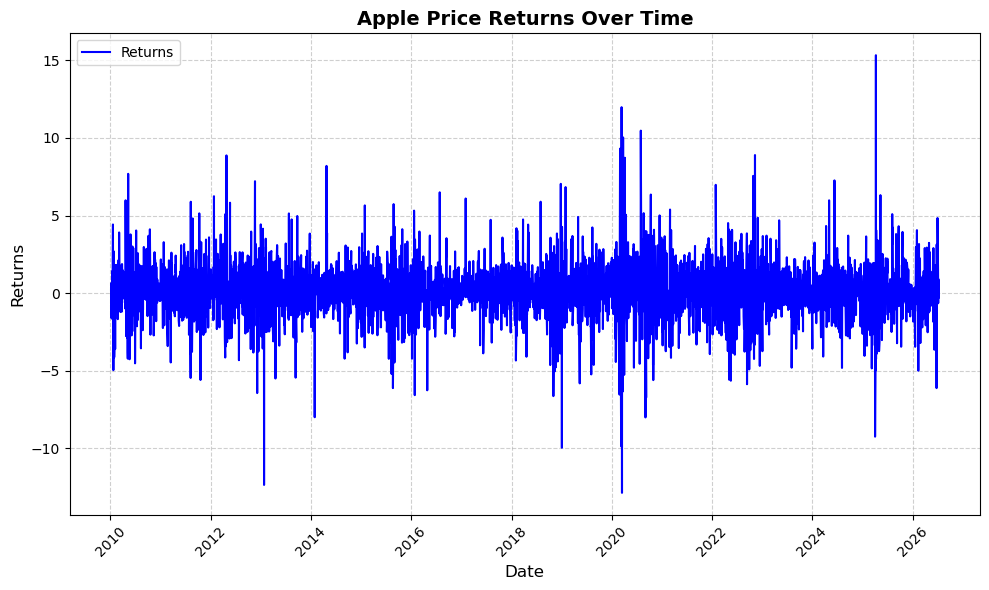

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df_apple['Date'], df_apple['Returns'], label='Returns', color='blue', linewidth=1.5)
ax.set_title('Apple Price Returns Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Returns', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


HDFC Bank (NSE) data: 2010-01-05 to 2026-07-10 (4079 rows)
Missing values check: {'Price': 0, 'Returns': 0}
No suspicious single-day price moves found.


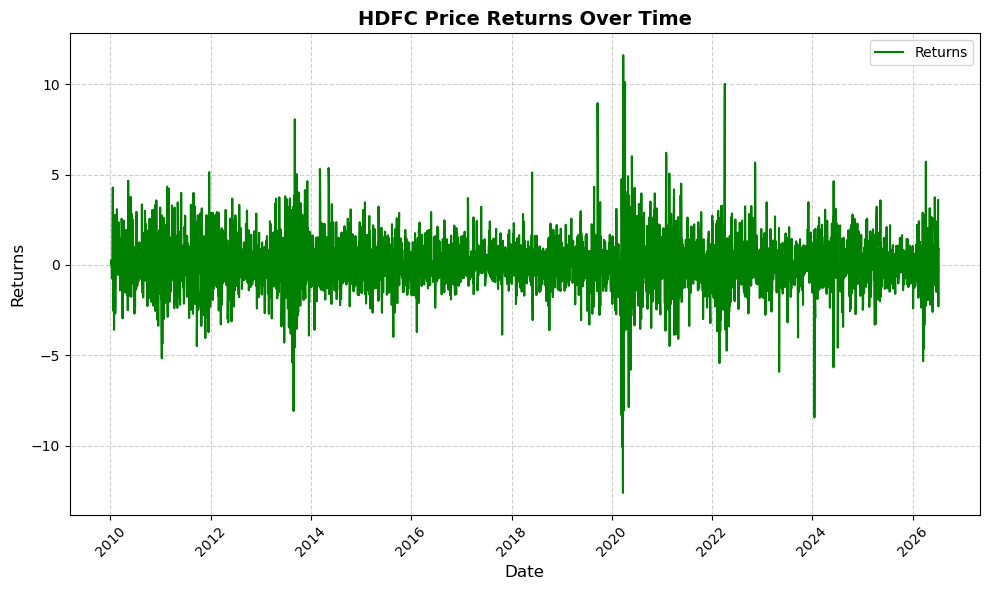

In [6]:
import yfinance as yf

# Pull HDFC Bank prices directly from Yahoo Finance.
# Own variable (df_hdfc_p1) - kept separate from df_hdfc used later in
hdfc_p1_raw = yf.download('HDFCBANK.NS', start='2010-01-01', interval='1d', progress=False, auto_adjust=True)

if isinstance(hdfc_p1_raw.columns, pd.MultiIndex):
    hdfc_p1_raw.columns = hdfc_p1_raw.columns.get_level_values(0)

df_hdfc_p1 = hdfc_p1_raw.reset_index()[['Date', 'Close']].rename(columns={'Close': 'Price'})
df_hdfc_p1['Date'] = pd.to_datetime(df_hdfc_p1['Date']).dt.tz_localize(None)
df_hdfc_p1 = df_hdfc_p1.dropna().sort_values('Date').reset_index(drop=True)

df_hdfc_p1['Returns'] = df_hdfc_p1['Price'].pct_change() * 100
df_hdfc_p1 = df_hdfc_p1.dropna().reset_index(drop=True)

print(f"HDFC Bank (NSE) data: {df_hdfc_p1['Date'].min().date()} to {df_hdfc_p1['Date'].max().date()} ({len(df_hdfc_p1)} rows)")
print("Missing values check:", df_hdfc_p1[['Price', 'Returns']].isna().sum().to_dict())

# Same data-quality check used for Gold/Bonds
suspects = df_hdfc_p1[df_hdfc_p1['Returns'].abs() > 20].copy()
if len(suspects) > 0:
    print(f"\nFound {len(suspects)} suspicious single-day move(s) > 20%:")
    print(suspects[['Date', 'Price', 'Returns']])
    for idx in suspects.index:
        if idx == 0 or idx >= len(df_hdfc_p1) - 1:
            continue
        price_before = df_hdfc_p1.loc[idx - 1, 'Price']
        price_spike = df_hdfc_p1.loc[idx, 'Price']
        price_after = df_hdfc_p1.loc[idx + 1, 'Price']
        if abs(price_after / price_before - 1) < 0.20:
            df_hdfc_p1.loc[idx, 'Price'] = (price_before + price_after) / 2
            print(f"  {df_hdfc_p1.loc[idx, 'Date'].date()}: single bad print - interpolated.")
        else:
            ratio = price_spike / price_before
            df_hdfc_p1.loc[:idx - 1, 'Price'] = df_hdfc_p1.loc[:idx - 1, 'Price'] * ratio
            print(f"  {df_hdfc_p1.loc[idx, 'Date'].date()}: persistent shift (ratio={ratio:.2f}) - rescaled.")
    df_hdfc_p1['Returns'] = df_hdfc_p1['Price'].pct_change() * 100
    df_hdfc_p1 = df_hdfc_p1.dropna().reset_index(drop=True)
else:
    print("No suspicious single-day price moves found.")

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df_hdfc_p1['Date'], df_hdfc_p1['Returns'], label='Returns', color='green', linewidth=1.5)
ax.set_title('HDFC Price Returns Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Returns', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Reliance Industries (NSE) data: 2010-01-05 to 2026-07-10 (4079 rows)
Missing values check: {'Price': 0, 'Returns': 0}
No suspicious single-day price moves found.


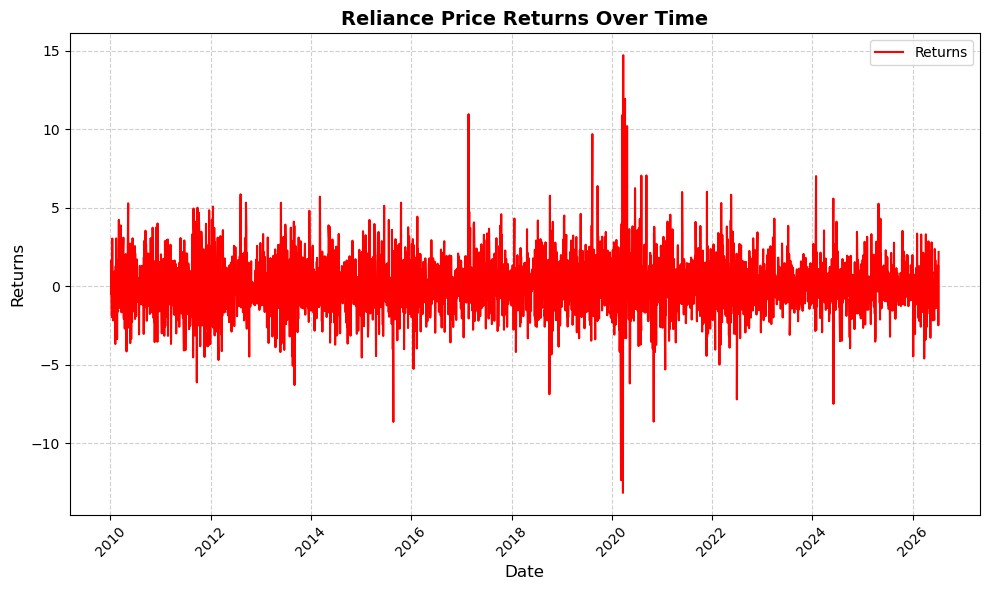

In [7]:
import yfinance as yf

# Pull Reliance Industries prices directly from Yahoo Finance.
reliance_raw = yf.download('RELIANCE.NS', start='2010-01-01', interval='1d', progress=False, auto_adjust=True)

if isinstance(reliance_raw.columns, pd.MultiIndex):
    reliance_raw.columns = reliance_raw.columns.get_level_values(0)

df_reliance = reliance_raw.reset_index()[['Date', 'Close']].rename(columns={'Close': 'Price'})
df_reliance['Date'] = pd.to_datetime(df_reliance['Date']).dt.tz_localize(None)
df_reliance = df_reliance.dropna().sort_values('Date').reset_index(drop=True)

df_reliance['Returns'] = df_reliance['Price'].pct_change() * 100
df_reliance = df_reliance.dropna().reset_index(drop=True)

print(f"Reliance Industries (NSE) data: {df_reliance['Date'].min().date()} to {df_reliance['Date'].max().date()} ({len(df_reliance)} rows)")
print("Missing values check:", df_reliance[['Price', 'Returns']].isna().sum().to_dict())

# Same data-quality check used for Gold/Bonds
suspects = df_reliance[df_reliance['Returns'].abs() > 20].copy()
if len(suspects) > 0:
    print(f"\nFound {len(suspects)} suspicious single-day move(s) > 20%:")
    print(suspects[['Date', 'Price', 'Returns']])
    for idx in suspects.index:
        if idx == 0 or idx >= len(df_reliance) - 1:
            continue
        price_before = df_reliance.loc[idx - 1, 'Price']
        price_spike = df_reliance.loc[idx, 'Price']
        price_after = df_reliance.loc[idx + 1, 'Price']
        if abs(price_after / price_before - 1) < 0.20:
            df_reliance.loc[idx, 'Price'] = (price_before + price_after) / 2
            print(f"  {df_reliance.loc[idx, 'Date'].date()}: single bad print - interpolated.")
        else:
            ratio = price_spike / price_before
            df_reliance.loc[:idx - 1, 'Price'] = df_reliance.loc[:idx - 1, 'Price'] * ratio
            print(f"  {df_reliance.loc[idx, 'Date'].date()}: persistent shift (ratio={ratio:.2f}) - rescaled.")
    df_reliance['Returns'] = df_reliance['Price'].pct_change() * 100
    df_reliance = df_reliance.dropna().reset_index(drop=True)
else:
    print("No suspicious single-day price moves found.")

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df_reliance['Date'], df_reliance['Returns'], label='Returns', color='red', linewidth=1.5)
ax.set_title('Reliance Price Returns Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Returns', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### India VIX — market fear gauge
Pulled directly from Yahoo Finance (`^INDIAVIX`) via `yfinance`, which gives full history rather than the ~1 year in the earlier CSV. It's still kept as a separate sanity-check/feature source below rather than blindly merged into the main HMM - always check the printed overlap window before relying on it, since yfinance can occasionally have gaps.

India VIX data: 2008-03-03 to 2026-07-10 (4495 rows)


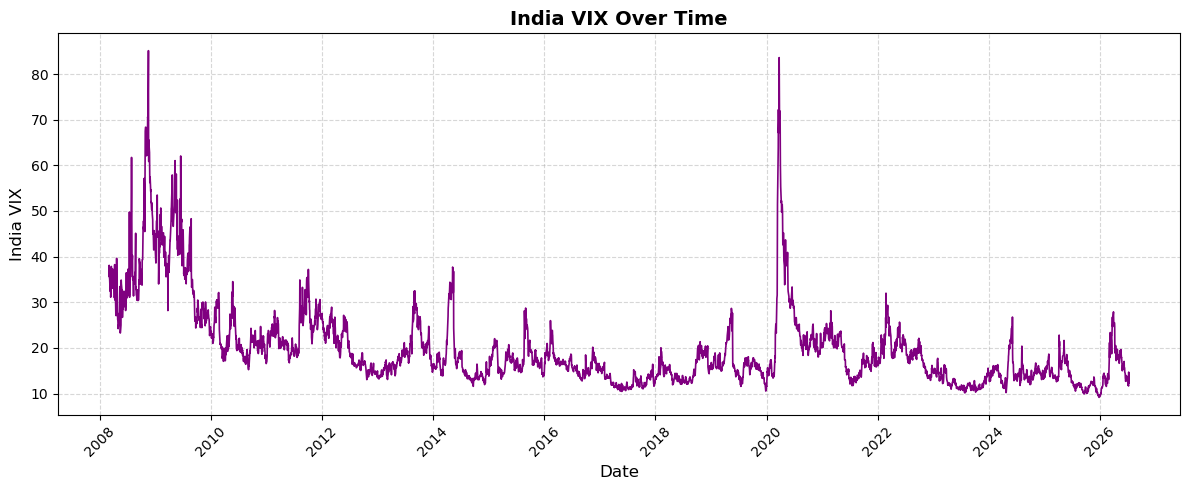

In [8]:
# Pull the India VIX (volatility index) directly from Yahoo Finance
import yfinance as yf

vix_raw = yf.download('^INDIAVIX', period='max', interval='1d', progress=False, auto_adjust=True)

if isinstance(vix_raw.columns, pd.MultiIndex):
    vix_raw.columns = vix_raw.columns.get_level_values(0)

vix_df = vix_raw.reset_index()[['Date', 'Close']].rename(columns={'Close': 'VIX_Close'})
vix_df['Date'] = pd.to_datetime(vix_df['Date']).dt.tz_localize(None)
vix_df = vix_df.dropna().sort_values('Date').reset_index(drop=True)

print(f"India VIX data: {vix_df['Date'].min().date()} to {vix_df['Date'].max().date()} ({len(vix_df)} rows)")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(vix_df['Date'], vix_df['VIX_Close'], color='purple', linewidth=1.2)
ax.set_title('India VIX Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('India VIX', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Phase 2 & 3 — Building momentum features and a NSE-based Regime Classifier (HDFC Bank)

This part include two important phases.
The creation of momentum and volatility features over rolling window.
Same HMM approach as above, but trained on an actual NSE stock — HDFC Bank (`HDFCBANK.NS`) — pulled directly from Yahoo Finance. 
Automation Bull/Bear/Crisis allocation.

In [9]:
import yfinance as yf

hdfc_raw = yf.download('HDFCBANK.NS', start='2010-01-01', interval='1d', progress=False, auto_adjust=True)

# yfinance sometimes returns MultiIndex columns even for a single ticker - flatten if so
if isinstance(hdfc_raw.columns, pd.MultiIndex):
    hdfc_raw.columns = hdfc_raw.columns.get_level_values(0)

df_hdfc = hdfc_raw.reset_index()[['Date', 'Close']].rename(columns={'Close': 'Price'})
df_hdfc['Date'] = pd.to_datetime(df_hdfc['Date']).dt.tz_localize(None)
df_hdfc = df_hdfc.dropna().sort_values('Date').reset_index(drop=True)

df_hdfc['Returns'] = df_hdfc['Price'].pct_change() * 100
df_hdfc = df_hdfc.dropna().reset_index(drop=True)

print(f"HDFC Bank (NSE) data: {df_hdfc['Date'].min().date()} to {df_hdfc['Date'].max().date()} ({len(df_hdfc)} rows)")
print(df_hdfc.head())


HDFC Bank (NSE) data: 2010-01-05 to 2026-07-10 (4079 rows)
Price       Date      Price   Returns
0     2010-01-05  73.789993  0.087962
1     2010-01-06  73.839706  0.067371
2     2010-01-07  74.032036  0.260469
3     2010-01-08  74.129288  0.131365
4     2010-01-11  73.831047 -0.402325


In [10]:
import numpy as np

def calculate_momentum(returns_pct, window):
    # returns_pct is in percent (e.g. 1.5 for +1.5%); convert to decimal for compounding
    return (returns_pct / 100 + 1).rolling(window=window).apply(np.prod, raw=True) - 1

df_hdfc['Momentum_1W'] = calculate_momentum(df_hdfc['Returns'], 5) * 100
df_hdfc['Momentum_1M'] = calculate_momentum(df_hdfc['Returns'], 21) * 100
df_hdfc['Momentum_1Q'] = calculate_momentum(df_hdfc['Returns'], 63) * 100

df_hdfc['volatility_1w'] = df_hdfc['Returns'].rolling(window=5).std()
df_hdfc['volatility_1m'] = df_hdfc['Returns'].rolling(window=21).std()
df_hdfc['volatility_1q'] = df_hdfc['Returns'].rolling(window=63).std()
df_hdfc['annualized_vol_1m'] = df_hdfc['volatility_1m'] * np.sqrt(252)

df_hdfc = df_hdfc.dropna().reset_index(drop=True)
print(df_hdfc.tail())


Price       Date       Price   Returns  Momentum_1W  Momentum_1M  Momentum_1Q  \
4012  2026-07-06  829.849976  3.595280     3.874071    12.920859     9.271407   
4013  2026-07-07  829.299988 -0.066276     3.928814    14.129303     3.298143   
4014  2026-07-08  810.299988 -2.291089     1.777299    11.559816     3.259603   
4015  2026-07-09  817.549988  0.894730     2.720186    11.276939     2.563471   
4016  2026-07-10  824.950012  0.905146     2.983587    12.623452     5.523371   

Price  volatility_1w  volatility_1m  volatility_1q  annualized_vol_1m  
4012        1.614067       1.343068       1.596337          21.320551  
4013        1.606949       1.294553       1.429005          20.550400  
4014        2.116131       1.438759       1.429966          22.839599  
4015        2.112664       1.434322       1.420809          22.769159  
4016        2.118591       1.423914       1.401967          22.603935  


Training HMM on 4017 HDFC Bank data points...

Best log-likelihood across 20 restarts: -7405.49
--- Mean Characteristics of Each Regime (HDFC Bank) ---
Price    Returns  volatility_1m
regime                         
0      -0.106293       1.181586
1       0.155806       1.017033
2       0.116525       2.096911

--- Transition Probability Matrix ---
         To 0   To 1   To 2
From 0  0.955  0.033  0.012
From 1  0.023  0.971  0.005
From 2  0.012  0.012  0.976

Self-transition (stickiness) probabilities: [0.955 0.971 0.976]
Low values (e.g. < 0.9) mean regimes are still switching too often day to day.

Regime switches - raw HMM output: 122, after causal smoothing: 119

--- Automatic Regime Labeling (HDFC Bank) ---
State 0 -> Bear   (avg return=-0.1063, avg vol=1.1816)
State 1 -> Bull   (avg return=0.1558, avg vol=1.0170)
State 2 -> Crisis (avg return=0.1165, avg vol=2.0969)


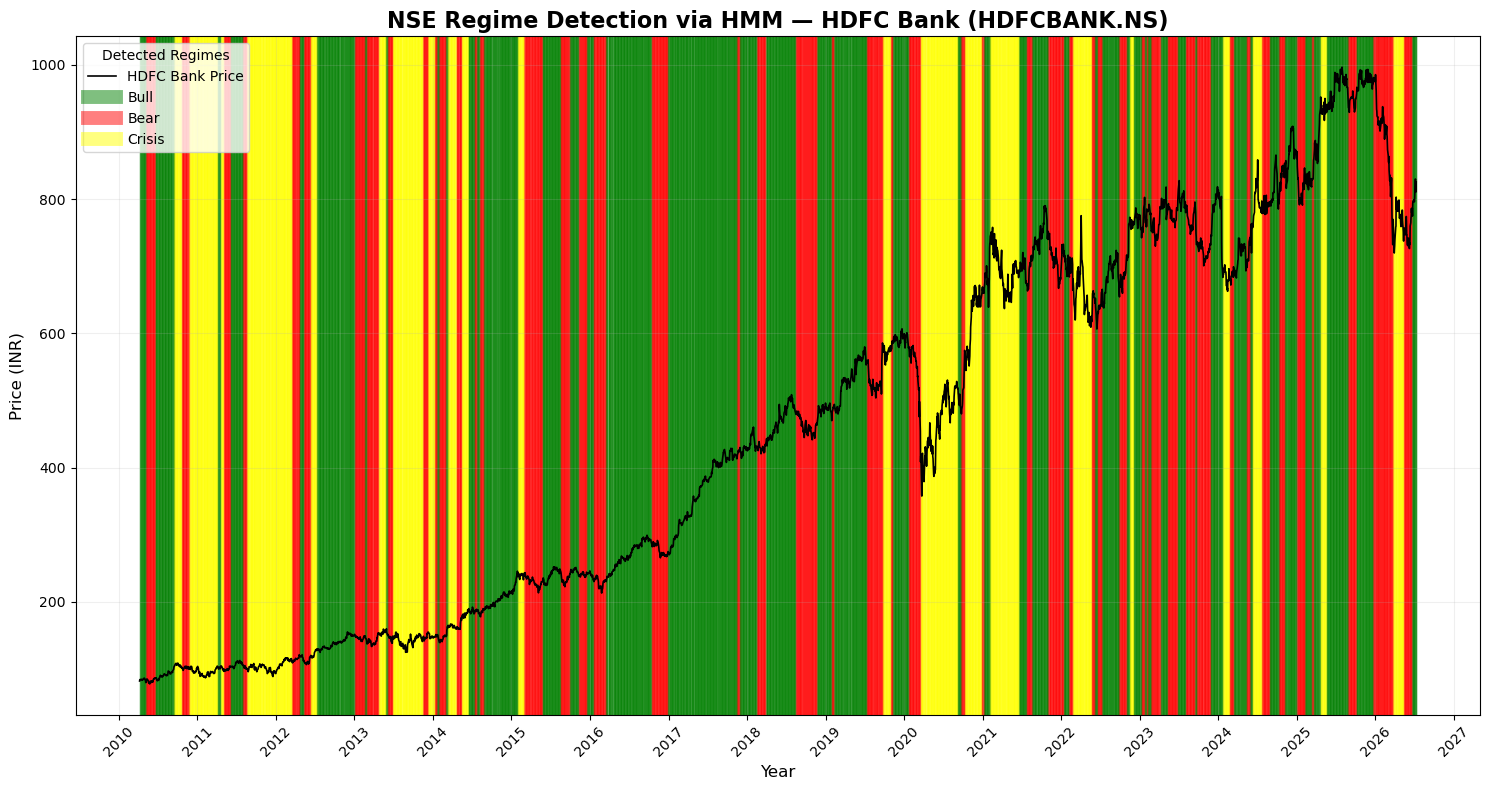

In [11]:
import matplotlib.dates as mdates
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

feature_cols = ['Momentum_1M', 'volatility_1m']

df_hdfc_model = df_hdfc.set_index('Date').copy()
df_hdfc_model.replace([np.inf, -np.inf], np.nan, inplace=True)
df_hdfc_model.dropna(subset=feature_cols, inplace=True)

np.random.seed(42)
df_hdfc_model['volatility_1m'] = df_hdfc_model['volatility_1m'] + np.random.normal(0, 1e-6, len(df_hdfc_model))

# Standardize features. Momentum_1M and volatility_1m live on different scales,
scaler = StandardScaler()
X_hdfc = scaler.fit_transform(df_hdfc_model[feature_cols].values)

print(f"Training HMM on {len(X_hdfc)} HDFC Bank data points...\n")

def causal_regime_smooth(labels, min_duration=5):
    smoothed = []
    current_label = None
    candidate_label = None
    candidate_count = 0
    for lab in labels:
        if current_label is None:
            current_label = lab
            smoothed.append(current_label)
            continue
        if lab == current_label:
            candidate_label = None
            candidate_count = 0
        else:
            if lab == candidate_label:
                candidate_count += 1
            else:
                candidate_label = lab
                candidate_count = 1
            if candidate_count >= min_duration:
                current_label = candidate_label
                candidate_label = None
                candidate_count = 0
        smoothed.append(current_label)
    return smoothed

best_model, best_score = None, -np.inf
for seed in range(20):
    candidate = GaussianHMM(n_components=3, covariance_type="diag", n_iter=200,
                             random_state=seed, min_covar=1e-3, init_params="mc")
    candidate.startprob_ = np.full(3, 1 / 3)
    candidate.transmat_ = np.full((3, 3), 0.02)
    np.fill_diagonal(candidate.transmat_, 0.96)
    candidate.fit(X_hdfc)
    score = candidate.score(X_hdfc)
    if score > best_score:
        best_score, best_model = score, candidate

hmm_hdfc = best_model
print(f"Best log-likelihood across 20 restarts: {best_score:.2f}")

df_hdfc_model['regime'] = hmm_hdfc.predict(X_hdfc)

print("--- Mean Characteristics of Each Regime (HDFC Bank) ---")
state_means_hdfc = df_hdfc_model.groupby('regime')[['Returns', 'volatility_1m']].mean()
print(state_means_hdfc)

print("\n--- Transition Probability Matrix ---")
print(pd.DataFrame(np.round(hmm_hdfc.transmat_, 3),
                   index=['From 0', 'From 1', 'From 2'],
                   columns=['To 0', 'To 1', 'To 2']))
print("\nSelf-transition (stickiness) probabilities:", np.round(np.diag(hmm_hdfc.transmat_), 3))
print("Low values (e.g. < 0.9) mean regimes are still switching too often day to day.")

# Automatic Bull / Bear / Crisis labeling
vol_rank = state_means_hdfc['volatility_1m'].sort_values(ascending=False)
crisis_state = vol_rank.index[0]
remaining_states = [s for s in state_means_hdfc.index if s != crisis_state]
remaining_returns = state_means_hdfc.loc[remaining_states, 'Returns']
bull_state = remaining_returns.idxmax()
bear_state = [s for s in remaining_states if s != bull_state][0]

state_to_label = {crisis_state: 'Crisis', bull_state: 'Bull', bear_state: 'Bear'}
df_hdfc_model['regime_label_raw'] = df_hdfc_model['regime'].map(state_to_label)
df_hdfc_model['regime_label'] = causal_regime_smooth(df_hdfc_model['regime_label_raw'].tolist(), min_duration=5)

raw_switches = (df_hdfc_model['regime_label_raw'] != df_hdfc_model['regime_label_raw'].shift()).sum()
smooth_switches = (df_hdfc_model['regime_label'] != df_hdfc_model['regime_label'].shift()).sum()
print(f"\nRegime switches - raw HMM output: {raw_switches}, after causal smoothing: {smooth_switches}")

print("\n--- Automatic Regime Labeling (HDFC Bank) ---")
for s in sorted(state_to_label):
    print(f"State {s} -> {state_to_label[s]:6s} "
          f"(avg return={state_means_hdfc.loc[s, 'Returns']:.4f}, "
          f"avg vol={state_means_hdfc.loc[s, 'volatility_1m']:.4f})")

fig, ax = plt.subplots(figsize=(15, 8))
ax.plot(df_hdfc_model.index, df_hdfc_model['Price'], color='black', linewidth=1.2, label='HDFC Bank Price')

label_colors = {'Bull': 'green', 'Bear': 'red', 'Crisis': 'yellow'}
for i in range(len(df_hdfc_model) - 1):
    label = df_hdfc_model['regime_label'].iloc[i]
    ax.axvspan(df_hdfc_model.index[i], df_hdfc_model.index[i + 1],
               color=label_colors[label], alpha=0.3)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

for label, color in label_colors.items():
    ax.plot([], [], color=color, alpha=0.5, linewidth=10, label=label)

plt.title('NSE Regime Detection via HMM — HDFC Bank (HDFCBANK.NS)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Price (INR)', fontsize=12)
plt.legend(loc='upper left', title="Detected Regimes")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


## Phase 4 — Walk-Forward Validation (HDFC Bank)

The Phase 3 classifier above is trained **once** on HDFC Bank's full history, then used to
label the entire history.
This section fixes that.
1. Train only on data strictly before the current point (the "past").
2. Fit the feature scaler on that training slice only, then apply it (never re-fit) to the
   next unseen chunk.
3. Re-fit a fresh HMM on the training slice, re-derive the Bull/Bear/Crisis mapping from
   *that window's* state means, and use it to label only the next chunk.
4. Slide forward and repeat.

A day's regime label should never depend on anything that happened after that day - that's
the property we verify explicitly at the end with a leakage check.

In [12]:
import warnings
warnings.filterwarnings("ignore")  # suppress hmmlearn's non-convergence warnings from restart attempts

from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler

feature_cols = ['Momentum_1M', 'volatility_1m']

def causal_regime_smooth(labels, min_duration=5):
    smoothed = []
    current_label = None
    candidate_label = None
    candidate_count = 0
    for lab in labels:
        if current_label is None:
            current_label = lab
            smoothed.append(current_label)
            continue
        if lab == current_label:
            candidate_label = None
            candidate_count = 0
        else:
            if lab == candidate_label:
                candidate_count += 1
            else:
                candidate_label = lab
                candidate_count = 1
            if candidate_count >= min_duration:
                current_label = candidate_label
                candidate_label = None
                candidate_count = 0
        smoothed.append(current_label)
    return smoothed

# Start from the HDFC Bank (Phase 3) data, sorted chronologically
wf_df = df_hdfc_model.copy()
wf_df = wf_df.replace([np.inf, -np.inf], np.nan).dropna(subset=feature_cols)
wf_df = wf_df.sort_index()

TRAIN_WINDOW = 504   # ~2 years of trading days for the initial training window
TEST_WINDOW  = 63    # ~1 quarter - re-fit and re-label every quarter
N_RESTARTS   = 10    # fewer restarts per window than the full-history fit, to keep runtime sane

wf_df['wf_regime'] = np.nan
wf_df['wf_regime_label_raw'] = None

n_windows = 0
start = TRAIN_WINDOW
while start < len(wf_df):
    train_slice = wf_df.iloc[:start]                       # everything up to 'start' - the past only
    test_end = min(start + TEST_WINDOW, len(wf_df))
    test_slice = wf_df.iloc[start:test_end]                # the next chunk - genuinely unseen at train time

 
    scaler = StandardScaler()
    X_train = scaler.fit_transform(train_slice[feature_cols].values)
    X_test = scaler.transform(test_slice[feature_cols].values)

    best_model, best_score = None, -np.inf
    for seed in range(N_RESTARTS):
        candidate = GaussianHMM(n_components=3, covariance_type="diag", n_iter=100,
                                 random_state=seed, min_covar=1e-3, init_params="mc")
        candidate.startprob_ = np.full(3, 1 / 3)
        candidate.transmat_ = np.full((3, 3), 0.02)
        np.fill_diagonal(candidate.transmat_, 0.96)
        candidate.fit(X_train)
        score = candidate.score(X_train)
        if score > best_score:
            best_score, best_model = score, candidate
    model = best_model
    train_regimes = model.predict(X_train)
    tmp = train_slice.copy()
    tmp['regime'] = train_regimes
    state_means = tmp.groupby('regime')[['Returns', 'volatility_1m']].mean()

    vol_rank = state_means['volatility_1m'].sort_values(ascending=False)
    crisis_state = vol_rank.index[0]
    remaining_states = [s for s in state_means.index if s != crisis_state]
    remaining_returns = state_means.loc[remaining_states, 'Returns']
    bull_state = remaining_returns.idxmax()
    bear_state = [s for s in remaining_states if s != bull_state][0]
    state_to_label = {crisis_state: 'Crisis', bull_state: 'Bull', bear_state: 'Bear'}

    # Predict the TEST chunk using only the model trained on the past
    test_regimes = model.predict(X_test)
    test_labels = [state_to_label[s] for s in test_regimes]

    wf_df.iloc[start:test_end, wf_df.columns.get_loc('wf_regime')] = test_regimes
    wf_df.iloc[start:test_end, wf_df.columns.get_loc('wf_regime_label_raw')] = test_labels

    n_windows += 1
    start += TEST_WINDOW

labeled = wf_df.dropna(subset=['wf_regime_label_raw']).copy()
labeled['wf_regime_label'] = causal_regime_smooth(labeled['wf_regime_label_raw'].tolist(), min_duration=5)
wf_df.loc[labeled.index, 'wf_regime_label'] = labeled['wf_regime_label']

raw_switches = (labeled['wf_regime_label_raw'] != labeled['wf_regime_label_raw'].shift()).sum()
smooth_switches = (labeled['wf_regime_label'] != labeled['wf_regime_label'].shift()).sum()

print(f"Walk-forward complete: {n_windows} windows, {wf_df['wf_regime_label'].notna().sum()} days labeled out-of-sample.")
print(f"Regime switches - raw walk-forward output: {raw_switches}, after causal smoothing: {smooth_switches}")
print(wf_df['wf_regime_label'].value_counts())


Walk-forward complete: 56 windows, 3513 days labeled out-of-sample.
Regime switches - raw walk-forward output: 174, after causal smoothing: 116
wf_regime_label
Bear      1550
Bull      1219
Crisis     744
Name: count, dtype: int64


In [13]:
# --- Leakage sanity check ---
# For every window, confirm the training slice ends strictly before the test
# slice begins in time (no overlap, no peeking). 
start = TRAIN_WINDOW
violations = 0
checked = 0
while start < len(wf_df):
    test_end = min(start + TEST_WINDOW, len(wf_df))
    train_dates = wf_df.index[:start]
    test_dates = wf_df.index[start:test_end]
    if len(train_dates) and len(test_dates):
        checked += 1
        if train_dates.max() >= test_dates.min():
            violations += 1
    start += TEST_WINDOW

print(f"Checked {checked} windows.")
print(f"Leakage violations found: {violations} (this must be 0)")
if violations == 0:
    print("No day's regime label was influenced by data from after that day.")


Checked 56 windows.
Leakage violations found: 0 (this must be 0)
No day's regime label was influenced by data from after that day.


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(15, 11), sharex=True)

label_colors = {'Bull': 'green', 'Bear': 'red', 'Crisis': 'yellow'}

# Top: in-sample (Phase 3) regimes - fit once on the full history
axes[0].plot(df_hdfc_model.index, df_hdfc_model['Price'], color='black', linewidth=1.0)
for i in range(len(df_hdfc_model) - 1):
    axes[0].axvspan(df_hdfc_model.index[i], df_hdfc_model.index[i + 1],
                     color=label_colors[df_hdfc_model['regime_label'].iloc[i]], alpha=0.3)
axes[0].set_title('In-Sample (Phase 3b): fit once on full history - has lookahead bias', fontsize=13)
axes[0].set_ylabel('Price (INR)')

# Bottom: walk-forward (Phase 4) regimes - each day labeled using only past data
wf_plot = wf_df.dropna(subset=['wf_regime_label'])
axes[1].plot(wf_plot.index, wf_plot['Price'], color='black', linewidth=1.0)
for i in range(len(wf_plot) - 1):
    axes[1].axvspan(wf_plot.index[i], wf_plot.index[i + 1],
                     color=label_colors[wf_plot['wf_regime_label'].iloc[i]], alpha=0.3)
axes[1].set_title('Walk-Forward (Phase 4): each day labeled using only data before it', fontsize=13)
axes[1].set_ylabel('Price (INR)')
axes[1].set_xlabel('Year')

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    for label, color in label_colors.items():
        ax.plot([], [], color=color, alpha=0.5, linewidth=10, label=label)
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.2)

plt.suptitle('HDFC Bank (HDFCBANK.NS) Regime Detection', fontsize=15, fontweight='bold', y=1.0)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



## Phase 5 — Connect Regimes to Portfolio Decisions and Backtest

Three assets, one per project brief: **HDFC Bank** (stocks), **LTGILTBEES.NS** (bonds - an
8-13yr NSE government gilt ETF, genuine duration exposure), and **GOLDBEES.NS** (gold). The
bond ETF only started trading in June 2016.

Every optimization below also estimates expected returns/covariance using only a trailing window of data strictly
before the rebalance date, for the same reason.

Regime -> objective mapping:
- **Bull**: maximize risk-adjusted return 
- **Bear**: minimize portfolio variance 
- **Crisis**: minimize variance *and* cap combined stock+gold exposure at 30% 

A small transaction cost (7.5 bps) is charged on portfolio turnover every time weights change,
so regime flips aren't secretly free.

In [ ]:
import yfinance as yf

# Pull the Bonds leg: Nippon India ETF Nifty 8-13 yr G-Sec Long Term Gilt -
# genuine long-duration Indian government bond exposure, NSE-listed.
# Own variable (df_bonds) so it isn't clobbered by other Phase 1 asset cells.
bonds_raw = yf.download('LTGILTBEES.NS', start='2010-01-01', interval='1d', progress=False, auto_adjust=True)

if isinstance(bonds_raw.columns, pd.MultiIndex):
    bonds_raw.columns = bonds_raw.columns.get_level_values(0)

df_bonds = bonds_raw.reset_index()[['Date', 'Close']].rename(columns={'Close': 'Price'})
df_bonds['Date'] = pd.to_datetime(df_bonds['Date']).dt.tz_localize(None)
df_bonds = df_bonds.dropna().sort_values('Date').reset_index(drop=True)

df_bonds['Returns'] = df_bonds['Price'].pct_change() * 100
df_bonds = df_bonds.dropna().reset_index(drop=True)

print(f"Bonds (LTGILTBEES.NS) raw data: {df_bonds['Date'].min().date()} to {df_bonds['Date'].max().date()} ({len(df_bonds)} rows)")

# Same data-quality check used for Gold: bonds are low-volatility, so a >15%
# single-day move is almost certainly a bad print or an un-adjusted corporate
# action, not a real move.
suspects = df_bonds[df_bonds['Returns'].abs() > 15].copy()

if len(suspects) > 0:
    print(f"\nFound {len(suspects)} suspicious single-day move(s) > 15%:")
    print(suspects[['Date', 'Price', 'Returns']])

    for idx in suspects.index:
        if idx == 0 or idx >= len(df_bonds) - 1:
            continue
        price_before = df_bonds.loc[idx - 1, 'Price']
        price_spike = df_bonds.loc[idx, 'Price']
        price_after = df_bonds.loc[idx + 1, 'Price']

        if abs(price_after / price_before - 1) < 0.15:
            df_bonds.loc[idx, 'Price'] = (price_before + price_after) / 2
            print(f"  {df_bonds.loc[idx, 'Date'].date()}: single bad print - interpolated.")
        else:
            ratio = price_spike / price_before
            df_bonds.loc[:idx - 1, 'Price'] = df_bonds.loc[:idx - 1, 'Price'] * ratio
            print(f"  {df_bonds.loc[idx, 'Date'].date()}: persistent shift (ratio={ratio:.2f}) - rescaled.")

    df_bonds['Returns'] = df_bonds['Price'].pct_change() * 100
    df_bonds = df_bonds.dropna().reset_index(drop=True)
else:
    print("No suspicious single-day price moves found.")

print(f"\nFinal Bonds (LTGILTBEES.NS) data: {df_bonds['Date'].min().date()} to {df_bonds['Date'].max().date()} ({len(df_bonds)} rows)")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_bonds['Date'], df_bonds['Price'], color='steelblue', linewidth=1.2)
ax.set_title('Bonds (LTGILTBEES.NS) Price Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price (INR)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# Combine all three assets on overlapping trading dates (inner join) - this is
# where the June 2016 bonds start date will naturally limit the backtest window.
combined_prices = pd.DataFrame({
    'HDFC': df_hdfc_model['Price'],
    'Gold': df_gold.set_index('Date')['Price'],
    'Bonds': df_bonds.set_index('Date')['Price'],
})

print("Missing values per asset BEFORE join (helps catch a bad source before it silently vanishes):")
print(combined_prices.isna().sum())

combined_prices = combined_prices.dropna()
combined_returns = combined_prices.pct_change().dropna()

print(f"\nCombined backtest window: {combined_returns.index.min().date()} to {combined_returns.index.max().date()}")
print(f"({len(combined_returns)} trading days)")

regime_series_raw = wf_df['wf_regime_label'].reindex(combined_returns.index).ffill()
regime_series_raw = regime_series_raw.fillna('Bull')  # safety net for any leading NaNs
regime_series = regime_series_raw.shift(1).bfill()  # bfill only to seed the very first day

print("\nRegime distribution over the backtest window (post-shift, as actually tradeable):")
print(regime_series.value_counts())


In [ ]:
import cvxpy as cp

ASSET_ORDER = ['HDFC', 'Gold', 'Bonds']  # index 0=HDFC (stock), 1=Gold, 2=Bonds

def optimize_weights(mu, cov, regime_label, risk_aversion=5.0, crisis_risky_cap=0.30):
    n = len(mu)
    w = cp.Variable(n)
    constraints = [cp.sum(w) == 1, w >= 0] 

    if regime_label == 'Bull':
        # Return-seeking: trade off expected return against variance
        objective = cp.Maximize(mu @ w - risk_aversion * cp.quad_form(w, cov))
    elif regime_label == 'Bear':
        # Defensive: minimize variance, no return target
        objective = cp.Minimize(cp.quad_form(w, cov))
    else:  # Crisis
        # Flight to safety: minimize variance AND cap combined stock+gold
        # exposure (indices 0 and 1) - forces meaningful allocation to bonds
        stock_idx, gold_idx = ASSET_ORDER.index('HDFC'), ASSET_ORDER.index('Gold')
        constraints.append(w[stock_idx] + w[gold_idx] <= crisis_risky_cap)
        objective = cp.Minimize(cp.quad_form(w, cov))

    prob = cp.Problem(objective, constraints)
    try:
        prob.solve()
        if w.value is None:
            raise ValueError("solver returned no solution")
        weights = np.clip(w.value, 0, None)
        return weights / weights.sum()
    except Exception as e:
        print(f"  [solver fallback to equal-weight due to: {e}]")
        return np.full(n, 1 / n)


def compute_metrics(daily_returns, periods_per_year=252, risk_free=0.0):
    equity = (1 + daily_returns).cumprod()
    n_days = len(daily_returns)

    ann_return = equity.iloc[-1] ** (periods_per_year / n_days) - 1
    ann_vol = daily_returns.std() * np.sqrt(periods_per_year)
    sharpe = (daily_returns.mean() * periods_per_year - risk_free) / ann_vol if ann_vol > 0 else np.nan

    downside = daily_returns[daily_returns < 0]
    downside_vol = downside.std() * np.sqrt(periods_per_year) if len(downside) > 1 else np.nan
    sortino = ((daily_returns.mean() * periods_per_year - risk_free) / downside_vol
               if downside_vol and downside_vol > 0 else np.nan)

    running_max = equity.cummax()
    drawdown = (equity - running_max) / running_max
    max_dd = drawdown.min()

    calmar = ann_return / abs(max_dd) if max_dd != 0 else np.nan

    return {
        'Annual Return': ann_return,
        'Annual Volatility': ann_vol,
        'Sharpe': sharpe,
        'Sortino': sortino,
        'Max Drawdown': max_dd,
        'Calmar': calmar,
    }, equity

print("Helper functions defined: optimize_weights(), compute_metrics()")


In [ ]:
LOOKBACK = 126          # ~6 months of trading days to estimate mu/cov - strictly before the rebalance date
REBALANCE_FREQ = 21     # ~1 month between rebalances
TRANSACTION_COST_BPS = 7.5

dates = combined_returns.index
n_assets = len(ASSET_ORDER)
returns_arr = combined_returns[ASSET_ORDER].values

current_weights = np.full(n_assets, 1 / n_assets)
portfolio_value = 1.0
values = []
weights_over_time = []
turnover_total = 0.0
n_rebalances = 0

for i, date in enumerate(dates):
    if i >= LOOKBACK and i % REBALANCE_FREQ == 0:
        hist = returns_arr[i - LOOKBACK:i]
        mu = hist.mean(axis=0)
        cov = np.cov(hist, rowvar=False)

        regime_today = regime_series.loc[date]
        new_weights = optimize_weights(mu, cov, regime_today)

        turnover = np.abs(new_weights - current_weights).sum()
        cost = turnover * (TRANSACTION_COST_BPS / 10000)
        portfolio_value *= (1 - cost)
        turnover_total += turnover
        n_rebalances += 1

        current_weights = new_weights

    day_return = np.dot(current_weights, returns_arr[i])
    portfolio_value *= (1 + day_return)
    values.append(portfolio_value)
    weights_over_time.append(current_weights.copy())

dynamic_equity_raw = pd.Series(values, index=dates)
dynamic_daily_returns = dynamic_equity_raw.pct_change().fillna(dynamic_equity_raw.iloc[0] - 1)
weights_df = pd.DataFrame(weights_over_time, index=dates, columns=ASSET_ORDER)

avg_annual_turnover = turnover_total / (len(dates) / 252)

print(f"Dynamic regime strategy: {n_rebalances} rebalances over {len(dates)} trading days")
print(f"Average annual turnover: {avg_annual_turnover:.2f}x portfolio value")
print(f"Final equity (growth of 1): {dynamic_equity_raw.iloc[-1]:.3f}")


In [ ]:
# Classic 60/40: 60% stocks (HDFC), 40% bonds - gold intentionally excluded,
# since "60/40" is specifically the textbook stock/bond benchmark.
weights_60_40 = np.array([0.60, 0.0, 0.40])  # [HDFC, Gold, Bonds]
returns_60_40 = combined_returns[ASSET_ORDER].values @ weights_60_40
equity_60_40 = pd.Series((1 + returns_60_40).cumprod(), index=dates)

# Equal-weight across all three assets we actually have
weights_eq = np.full(3, 1 / 3)
returns_eq = combined_returns[ASSET_ORDER].values @ weights_eq
equity_eq = pd.Series((1 + returns_eq).cumprod(), index=dates)

print("Static benchmarks computed.")
print(f"60/40 final equity: {equity_60_40.iloc[-1]:.3f}")
print(f"Equal-weight final equity: {equity_eq.iloc[-1]:.3f}")


In [ ]:
# --- Performance comparison table ---
dynamic_metrics, _ = compute_metrics(dynamic_daily_returns.dropna())
metrics_60_40, _ = compute_metrics(pd.Series(returns_60_40, index=dates))
metrics_eq, _ = compute_metrics(pd.Series(returns_eq, index=dates))

comparison = pd.DataFrame({
    'Dynamic (Regime-Based)': dynamic_metrics,
    'Static 60/40': metrics_60_40,
    'Equal-Weight': metrics_eq,
}).T

comparison['Annual Return'] = (comparison['Annual Return'] * 100).round(2).astype(str) + '%'
comparison['Annual Volatility'] = (comparison['Annual Volatility'] * 100).round(2).astype(str) + '%'
comparison['Max Drawdown'] = (comparison['Max Drawdown'] * 100).round(2).astype(str) + '%'
comparison['Sharpe'] = comparison['Sharpe'].round(3)
comparison['Sortino'] = comparison['Sortino'].round(3)
comparison['Calmar'] = comparison['Calmar'].round(3)

print("=== Strategy Comparison ===\n")
print(comparison.to_string())
print(f"\nDynamic strategy average annual turnover: {avg_annual_turnover:.2f}x")
print("(Static benchmarks have ~0 turnover under the constant-weight approximation used above.)")


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(15, 11), gridspec_kw={'height_ratios': [2, 1]})

# Top: equity curves
axes[0].plot(dynamic_equity_raw.index, dynamic_equity_raw.values, label='Dynamic (Regime-Based)', color='navy', linewidth=1.5)
axes[0].plot(equity_60_40.index, equity_60_40.values, label='Static 60/40', color='darkorange', linewidth=1.3, linestyle='--')
axes[0].plot(equity_eq.index, equity_eq.values, label='Equal-Weight', color='gray', linewidth=1.3, linestyle=':')
axes[0].set_title('Growth of ₹1: Dynamic Regime Strategy vs. Static Benchmarks', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Portfolio Value (starting at 1.0)')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# Bottom: how the dynamic strategy's allocation shifted over time
axes[1].stackplot(weights_df.index, weights_df['HDFC'], weights_df['Gold'], weights_df['Bonds'],
                   labels=['HDFC (Stock)', 'Gold', 'Bonds'],
                   colors=['#4C72B0', '#DD8452', '#55A868'], alpha=0.85)
axes[1].set_title('Dynamic Strategy: Allocation Over Time', fontsize=13)
axes[1].set_ylabel('Weight')
axes[1].set_xlabel('Year')
axes[1].legend(loc='upper left', ncol=3, fontsize=9)
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()